In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [18]:
import subprocess
from pathlib import Path

N = 100
EXE_PATH = "./tools/target/release/vis.exe"
for i in range(N):
    input_txt_path = f"./in/{str(i).zfill(4)}.txt"
    output_txt_path = f"./out/{str(i).zfill(4)}.txt"
    result_txt_path = f"./result/{str(i).zfill(4)}.txt"
    ret = subprocess.run([EXE_PATH, input_txt_path, output_txt_path, result_txt_path])

In [19]:
class Env:

    def __init__(self, input_txt_path: Path, output_txt_path, result_txt_path):
        self.W, self.D, self.N, self.a = self._input(input_txt_path)

        self.ans: list[list[int]] = []
        with open(output_txt_path, mode="r") as file:
            lines = file.readlines()
            for line in lines:
                self.ans.append(list(map(int, line.split())))

        with open(result_txt_path, mode="r") as file:
            lines = file.readlines()
            self.score = int(lines[0].strip())

    def _input(self, txt_path):
        with open(txt_path, mode="r") as file:
            lines = file.readlines()
        W, D, N = map(int, lines[0].split())
        a = []
        for line, d in zip(lines[1:], range(D)):
            d = list(map(int, line.split()))
            a.append(d)
        return W, D, N, a

In [20]:
envs = []
for i in range(N):
    input_txt_path = f"./in/{str(i).zfill(4)}.txt"
    output_txt_path = f"./out/{str(i).zfill(4)}.txt"
    result_txt_path = f"./result/{str(i).zfill(4)}.txt"
    envs.append(Env(input_txt_path, output_txt_path, result_txt_path))

In [21]:
scores = [env.score for env in envs]
ave_score = sum(scores) / N
total_score = sum(scores)

print(f"ave_score: {ave_score}, total_score: {total_score}")

ave_score: 927855.65, total_score: 92785565


In [44]:
ave_areas = []
for env in envs:
    sum_areas = []
    for areas in env.a:
        sum_areas.append(sum(area for area in areas) / (1000 ** 2))
    ave_areas.append(sum(sum_areas) / env.D)

In [45]:
ave_areas

[0.7772258000000001,
 0.9848716800000001,
 0.95690792,
 0.9464770909090909,
 0.9724773333333333,
 0.7619683061224491,
 0.9253572,
 0.8143139333333335,
 0.9153425384615385,
 0.7986046666666667,
 0.959044714285714,
 0.9421448333333333,
 0.7672852820512819,
 0.9681000416666666,
 0.9413135652173914,
 0.9078799583333333,
 0.9712899090909091,
 0.9151146875,
 0.7589208529411764,
 0.965591108108108,
 0.9760070555555553,
 0.81981076,
 0.7866913571428569,
 0.8429318620689656,
 0.9259218888888887,
 0.824209148148148,
 0.8190349999999998,
 0.943525576923077,
 0.7959141428571429,
 0.7997684736842107,
 0.9307737999999999,
 0.9654289655172414,
 0.7726421111111111,
 0.978809875,
 0.9957227,
 0.7828737999999998,
 0.8234136739130434,
 0.9402282307692308,
 0.9542838461538461,
 0.992771857142857,
 0.8145389361702128,
 0.8442694999999999,
 0.8750148275862067,
 0.9002489999999999,
 0.9101256666666667,
 0.9802492916666666,
 0.9758935833333336,
 0.992279882352941,
 0.809877375,
 0.9096662999999998,
 0.9385035

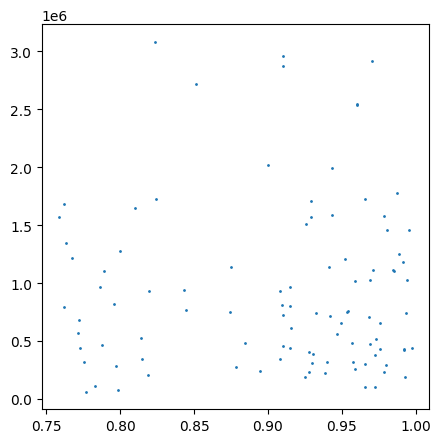

In [28]:
plt.figure(figsize=(5, 5))
plt.scatter(ave_areas, scores, s=1)
plt.show()

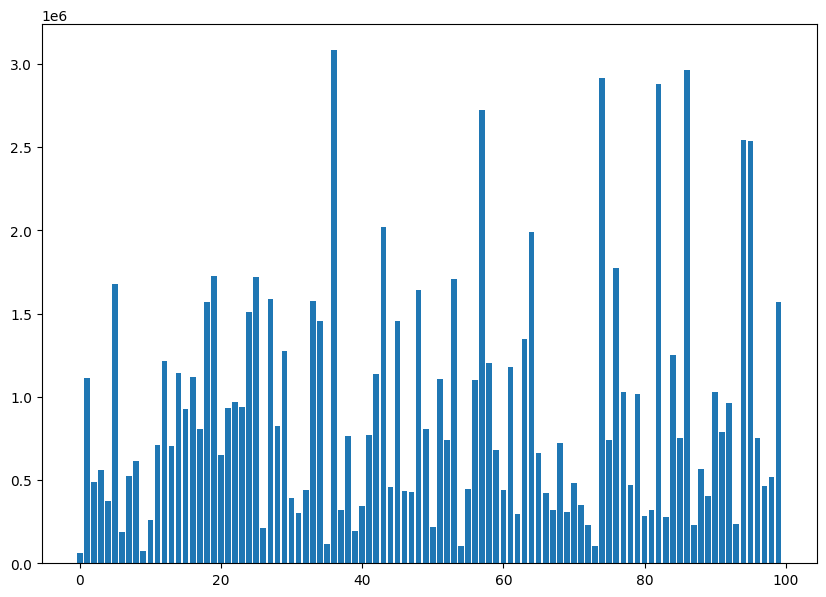

In [23]:
scores = [env.score for env in envs]
indexes = [i for i in range(N)]

plt.figure(figsize=(10, 7))
plt.bar(indexes, scores)
plt.show()

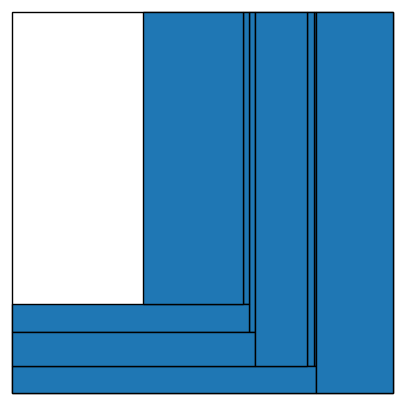

In [35]:
test_points = envs[0].ans[0:envs[0].N]

def display_map(points):
    fig = plt.figure(figsize=(5, 5))
    ax = plt.axes()

    r = patches.Rectangle(xy=(0, 0), width=1000, height=1000, ec='#000000', fill=False)
    ax.add_patch(r)

    for vec in points:
        x1, y1, x2, y2 = vec[0], vec[1], vec[2], vec[3]
        w, h = x2 - x1, y2 - y1
        r = patches.Rectangle(xy=(x1, y1), width=w, height=h, ec='#000000', fill=True)
        ax.add_patch(r)

    plt.xlim(-5, 1005)
    plt.ylim(-5, 1005)
    plt.axis('off')
    ax.set_aspect('equal')
    plt.show()

display_map(test_points)